## Import Libraries

In [3]:
# added for ML phase feedback
from sklearn.linear_model import Ridge

In [4]:
# Basic libraries
import pandas as pd
import numpy as np

# Sklearn for model testing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# For visualization
import matplotlib.pyplot as plt

In [5]:
# Reading the dataset again -> since working on a new notebook, these steps are quite similar to the EDA & Hypothesis Testing
tourism = pd.read_csv("world_tourism_.csv")
quality = pd.read_csv("quality_of_life_indices_by_country.csv")

In [6]:
# on the tourism dataset -> 'country'
# on the quality -> 'Country'
tourism["country"] = tourism["country"].str.strip().str.lower()
quality["Country"] = quality["Country"].str.strip().str.lower()

In [7]:
# quality dataset has years like "2015", "2015/2"...
# I extract the main year part
quality["year"] = quality["Year"].astype(str).str.extract(r"(\d{4})").astype(int)

# Equalize each country column
quality = quality.rename(columns={"Country": "country"})

In [8]:
# Normalize the gdp with num of people
tourism["tourism_gdp_ratio"] = tourism["tourism_receipts"] / tourism["gdp"]

# Remove impossible or missing values
tourism = tourism.replace([np.inf, -np.inf], np.nan)
tourism_ml = tourism[["country", "year", "tourism_receipts", "gdp", "inflation", "unemployment", "tourism_gdp_ratio"]].dropna()

In [9]:
# Preparing quality dataset
# We are adding some new indecies to increase the project focus
# Main focus is stil safety vs affordibility
quality_features = [
    "country",
    "year",
    "Quality of Life Index",
    "Purchasing Power Index",
    "Safety Index",
    "Health Care Index",
    "Cost of Living Index",
    "Property Price to Income Ratio",
    "Traffic Commute Time Index",
    "Pollution Index"
]

quality_ml = quality[quality_features].copy()

# Converting numeric columns
for col in quality_ml.columns:
    if col not in ["country", "year"]:
        quality_ml[col] = pd.to_numeric(quality_ml[col], errors="coerce")

# Some years have two observations such as 2015 and 2015/2
# I take the average for each country-year pair
quality_ml = quality_ml.groupby(["country", "year"], as_index=False).mean()

In [10]:
# Merging tourism and quality datasets
df_ml = tourism_ml.merge(
    quality_ml,
    on=["country", "year"],
    how="inner"
)

df_ml = df_ml.dropna()

print("Final ML dataset shape:", df_ml.shape)
print(df_ml.head())

Final ML dataset shape: (319, 15)
     country  year  tourism_receipts           gdp  inflation  unemployment  \
0  argentina  2015      5.441000e+09  5.947493e+11  34.277224         7.579   
1  argentina  2016      5.466000e+09  5.575323e+11  34.277224         8.085   
2  argentina  2017      5.830000e+09  6.436284e+11  34.277224         8.347   
3  argentina  2018      5.999000e+09  5.248199e+11  34.277224         9.221   
4  argentina  2019      5.654000e+09  4.477547e+11  53.548304         9.843   

   tourism_gdp_ratio  Quality of Life Index  Purchasing Power Index  \
0           0.009148                  84.90                   71.50   
1           0.009804                 137.90                   68.10   
2           0.009058                 129.65                   54.60   
3           0.011431                 131.10                   60.85   
4           0.012627                 121.75                   53.50   

   Safety Index  Health Care Index  Cost of Living Index  \
0   

In [11]:
# Defining target and features
target = "tourism_gdp_ratio"

features = [
    "year",
    "inflation",
    "unemployment",
    "Quality of Life Index",
    "Purchasing Power Index",
    "Safety Index",
    "Health Care Index",
    "Cost of Living Index",
    "Property Price to Income Ratio",
    "Traffic Commute Time Index",
    "Pollution Index"
]

X = df_ml[features]
y = df_ml[target]

In [12]:
# Changed wrt the feedback for ML phase
train_data = df_ml[df_ml["year"] < 2019]
test_data = df_ml[df_ml["year"] == 2019]

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (207, 11)
Test size: (55, 11)


In [13]:
# Defining a function for evaluation of each model
def evaluate_model(model_name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"{model_name} Performance")
    print("-------------------------")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R²:", r2)
    print()

    return mae, rmse, r2

## Linear Regression



In [14]:
# Training a Linear Regression
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

linear_results = evaluate_model("Linear Regression", y_test, y_pred_linear)

Linear Regression Performance
-------------------------
MAE: 0.032753172526329685
RMSE: 0.04077808814633446
R²: 0.2754149225879362



In [15]:
# Linear Regression coefficients
linear_coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": linear_model.named_steps["model"].coef_
}).sort_values(by="Coefficient", ascending=False)

print("Linear Regression Coefficients:")
print(linear_coefficients)

Linear Regression Coefficients:
                           Feature  Coefficient
5                     Safety Index     0.013273
7             Cost of Living Index     0.007563
2                     unemployment     0.007509
6                Health Care Index     0.007059
10                 Pollution Index     0.005671
0                             year     0.002801
1                        inflation    -0.006064
8   Property Price to Income Ratio    -0.008933
9       Traffic Commute Time Index    -0.009186
3            Quality of Life Index    -0.009395
4           Purchasing Power Index    -0.018901


## Random Forest

In [16]:
# Training a Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=6
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_results = evaluate_model("Random Forest Regressor", y_test, y_pred_rf)

Random Forest Regressor Performance
-------------------------
MAE: 0.019702203840241884
RMSE: 0.03204473878650424
R²: 0.5525452357545984



## Feature Importance for Random Forest

In [17]:
# Random Forest feature importance
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Random Forest Feature Importance:")
print(feature_importance)

Random Forest Feature Importance:
                           Feature  Importance
2                     unemployment    0.286665
7             Cost of Living Index    0.174928
9       Traffic Commute Time Index    0.121399
5                     Safety Index    0.094052
10                 Pollution Index    0.093377
4           Purchasing Power Index    0.066449
1                        inflation    0.057647
8   Property Price to Income Ratio    0.043965
6                Health Care Index    0.038716
3            Quality of Life Index    0.019382
0                             year    0.003421


## Feature Importance Visualization

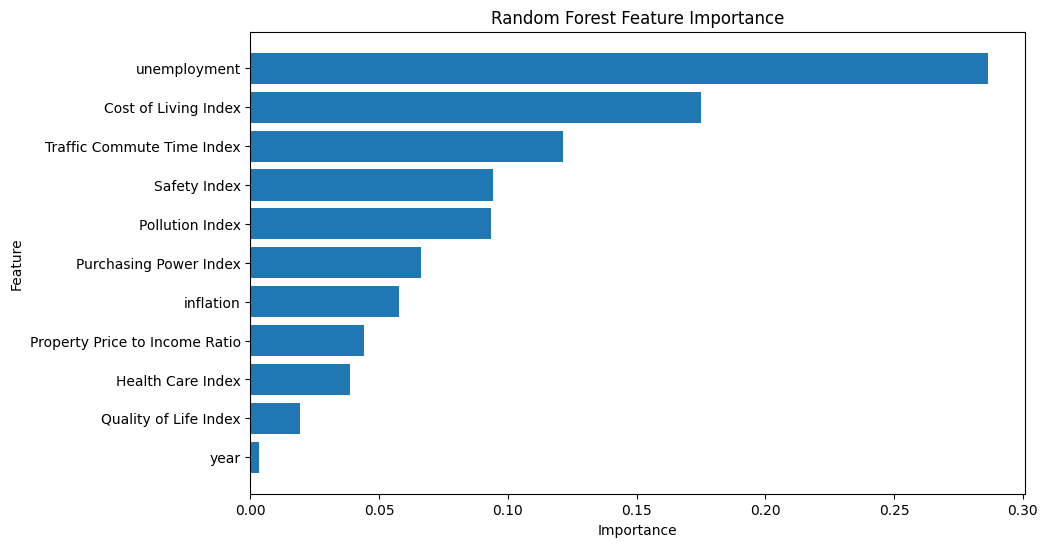

In [18]:
# Feature importance visualization
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

## Ridge Regression


In [19]:
# Added after ML phase feedback
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

ridge_results = evaluate_model(
    "Ridge Regression",
    y_test,
    y_pred_ridge
)

Ridge Regression Performance
-------------------------
MAE: 0.03275074341874541
RMSE: 0.04081060109420681
R²: 0.27425901804977704



## Comparing Models

In [20]:
# Changed after ML phase feedback
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_results[0],
        ridge_results[0],
        rf_results[0]
    ],
    "RMSE": [
        linear_results[1],
        ridge_results[1],
        rf_results[1]
    ],
    "R2": [
        linear_results[2],
        ridge_results[2],
        rf_results[2]
    ]
})

print(results_df)

               Model       MAE      RMSE        R2
0  Linear Regression  0.032753  0.040778  0.275415
1   Ridge Regression  0.032751  0.040811  0.274259
2      Random Forest  0.019702  0.032045  0.552545


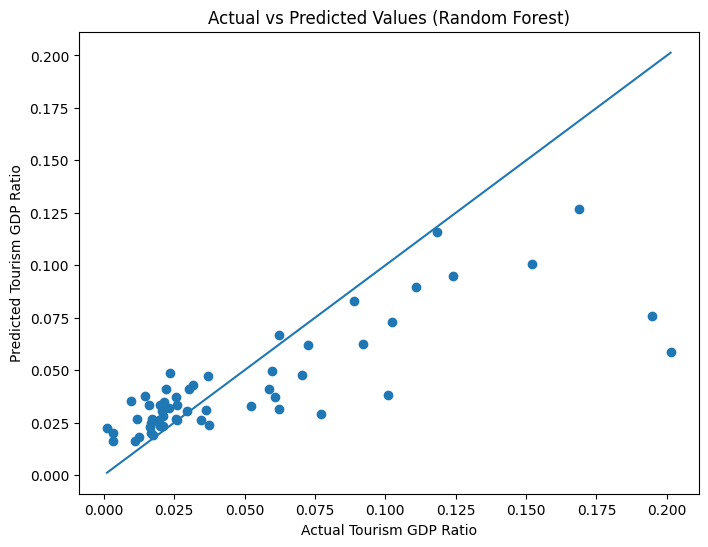

In [21]:
# Added after the ML phase feedback
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Tourism GDP Ratio")
plt.ylabel("Predicted Tourism GDP Ratio")

plt.title("Actual vs Predicted Values (Random Forest)")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()